# Polymarket × Deribit: Combined Data Pull

Fetches active Polymarket BTC contracts and the nearest Deribit option chain for each contract's expiry, then joins them into a single comparison table.

This notebook validates the `polymarket_data_pull` branch implementation against the existing `src/deribit.py` infrastructure.

In [1]:
import sys
sys.path.insert(0, '..')  # project root

import pandas as pd
from datetime import datetime, timezone

from src.polymarket import get_btc_contracts
from src.deribit import get_option_chain, find_nearest_expiry

## 1. Fetch Polymarket Contracts

In [2]:
contracts = get_btc_contracts()
print(f"Fetched {len(contracts)} BTC contracts")

Fetching liquid BTC markets (Sorted by Volume)...
Scanning page 1...
JUST FOR TEST USE: Fake BTC price from Binance retrieval for start time: 2026-06-26T23:00:00+00:00
Scanning page 2...
Scanning page 3...
JUST FOR TEST USE: Fake BTC price from Binance retrieval for start time: 2026-06-26T14:30:00+00:00
Scanning page 4...
Scanning page 5...
Scanning page 6...
JUST FOR TEST USE: Fake BTC price from Binance retrieval for start time: 2026-06-27T01:00:00+00:00
Scanning page 7...
Scanning page 8...
Scanning page 9...
JUST FOR TEST USE: Fake BTC price from Binance retrieval for start time: 2026-06-26T16:00:00+00:00
Scanning page 10...
Scanning page 11...
JUST FOR TEST USE: Fake BTC price from Binance retrieval for start time: 2026-06-26T15:00:00+00:00
Scanning page 12...
JUST FOR TEST USE: Fake BTC price from Binance retrieval for start time: 2026-06-26T16:00:00+00:00
JUST FOR TEST USE: Fake BTC price from Binance retrieval for start time: 2026-06-25T16:00:00+00:00
Scanning page 13...
Scanni

In [6]:
# Build a clean DataFrame of Polymarket contracts
def ts_to_date(ts):
    return datetime.fromtimestamp(ts, tz=timezone.utc).strftime("%Y-%m-%d %H:%M UTC")

poly_rows = []
for c in contracts:
    poly_rows.append({
        "contract_id":          c.contract_id[:10] + "...",
        "question":             c.question,
        "bet_type":             c.bet_type,
        "strike_low":           c.strike_low,
        "strike_high":          c.strike_high,
        "poly_price":           c.polymarket_price,
        "resolution_ts":        c.resolution_timestamp,
        "resolution_date":      ts_to_date(c.resolution_timestamp),
    })

poly_df = pd.DataFrame(poly_rows)

print(f"\nBet type breakdown:")
print(poly_df["bet_type"].value_counts().to_string())
print(f"\nContracts with parseable strike (strike_low not null):")
print(f"  {poly_df['strike_low'].notna().sum()} / {len(poly_df)}")


Bet type breakdown:
bet_type
above     106
reach      50
range      46
dip        31
UpDown     10
below       6

Contracts with parseable strike (strike_low not null):
  166 / 249


In [9]:
# Show all non-UpDown contracts with valid strikes — these are the priceable ones
priceable = poly_df[
    (poly_df["bet_type"].isin(["above", "range", "dip"])) &
    (poly_df["strike_low"].notna())
# to view below contracts, remove not na condition for strike_low, add "below" to list
].copy().sort_values("resolution_ts")

print(f"{len(priceable)} priceable contracts (above / range / dip with known strike)\n")
pd.set_option("display.max_colwidth", 70)
print(priceable[["bet_type", "strike_low", "strike_high", "poly_price", "resolution_date", "question"]].to_string())

156 priceable contracts (above / range / dip with known strike)

    bet_type    strike_low  strike_high  poly_price       resolution_date                                                              question
141    above  6.040000e+04          NaN      0.4150  2026-06-26 15:00 UTC                             Bitcoin above 60,400 on June 26, 11AM ET?
233    above  5.860000e+04          NaN      0.5000  2026-06-26 15:00 UTC                             Bitcoin above 58,600 on June 26, 11AM ET?
66     above  5.940000e+04          NaN      0.9450  2026-06-26 15:00 UTC                             Bitcoin above 59,400 on June 26, 11AM ET?
23     above  6.060000e+04          NaN      0.4000  2026-06-26 15:00 UTC                             Bitcoin above 60,600 on June 26, 11AM ET?
217    above  5.960000e+04          NaN      0.9000  2026-06-26 15:00 UTC                             Bitcoin above 59,600 on June 26, 11AM ET?
101    above  6.200000e+04          NaN      0.0165  2026-06-26 16:00 U

## 2. Fetch Deribit Option Chains

For each unique resolution date we find the nearest Deribit expiry and pull the option chain once (avoiding duplicate fetches for contracts that share an expiry).

In [10]:
import logging
logging.basicConfig(level=logging.WARNING)  # suppress INFO noise from the fetcher

# Unique resolution timestamps across all priceable contracts
unique_expiries = priceable["resolution_ts"].unique()
print(f"Unique Polymarket resolution dates: {len(unique_expiries)}")

# Map each to the nearest Deribit expiry and fetch chains
chains = {}  # deribit_expiry_ms -> OptionChain
poly_to_deribit = {}  # poly resolution_ts -> deribit_expiry_ms

for poly_ts in sorted(unique_expiries):
    deribit_ts = find_nearest_expiry(int(poly_ts))
    poly_to_deribit[poly_ts] = deribit_ts

    if deribit_ts not in chains:
        exp_date = datetime.fromtimestamp(deribit_ts / 1000, tz=timezone.utc).strftime("%Y-%m-%d")
        print(f"  Fetching chain for Deribit expiry {exp_date} (mapped from poly {ts_to_date(poly_ts)})...")
        chain = get_option_chain(deribit_ts)
        if chain is not None:
            chains[deribit_ts] = chain
            print(f"    -> {len(chain.quotes)} instruments, spot={chain.underlying_price:,.0f}, T={chain.time_to_expiry:.4f}y")
        else:
            print(f"    -> no chain (no market at this expiry)")

print(f"\nFetched {len(chains)} distinct option chains")

Unique Polymarket resolution dates: 12
  Fetching chain for Deribit expiry 2026-06-27 (mapped from poly 2026-06-26 13:00 UTC)...
    -> 23 instruments, spot=59,192, T=0.0022y
  Fetching chain for Deribit expiry 2026-06-28 (mapped from poly 2026-06-28 16:00 UTC)...
    -> 29 instruments, spot=59,188, T=0.0049y
  Fetching chain for Deribit expiry 2026-06-29 (mapped from poly 2026-06-29 04:00 UTC)...
    -> 27 instruments, spot=59,187, T=0.0077y
  Fetching chain for Deribit expiry 2026-06-30 (mapped from poly 2026-06-30 16:00 UTC)...
    -> 24 instruments, spot=59,181, T=0.0104y
  Fetching chain for Deribit expiry 2026-07-03 (mapped from poly 2026-07-02 16:00 UTC)...


    -> 29 instruments, spot=59,191, T=0.0186y
  Fetching chain for Deribit expiry 2026-12-25 (mapped from poly 2027-01-01 05:00 UTC)...
    -> 82 instruments, spot=60,249, T=0.4981y

Fetched 6 distinct option chains


## 3. Inspect One Option Chain

Pick the first available chain and inspect the IV smile.

In [11]:
# Pick the nearest expiry chain with data
first_chain = next(iter(chains.values()))
exp_str = datetime.fromtimestamp(first_chain.expiry_timestamp / 1000, tz=timezone.utc).strftime("%Y-%m-%d")

print(f"Chain expiry : {exp_str}")
print(f"Spot price   : ${first_chain.underlying_price:,.2f}")
print(f"Time to expiry: {first_chain.time_to_expiry:.6f} years ({first_chain.time_to_expiry*365:.2f} days)")
print(f"Total instruments: {len(first_chain.quotes)}")
print()

calls = first_chain.quotes[first_chain.quotes["option_type"] == "call"].copy()
puts  = first_chain.quotes[first_chain.quotes["option_type"] == "put"].copy()
print(f"  Calls: {len(calls)}, Puts: {len(puts)}")
print()

calls[["strike", "bid_iv", "ask_iv", "mid_iv", "mid_price", "open_interest", "delta"]].head(10)

Chain expiry : 2026-06-27
Spot price   : $59,191.82
Time to expiry: 0.002175 years (0.79 days)
Total instruments: 23

  Calls: 10, Puts: 13



,strike,bid_iv,ask_iv,mid_iv,mid_price,open_interest,delta
9,58500.0,0.6641,0.7505,0.70730,1169.038445,37.7,0.64132
12,59000.0,0.6629,0.7170,0.68995,858.281390,58.0,0.54680
13,59500.0,0.6120,0.6664,0.63920,562.322290,122.6,0.43783
15,60000.0,0.5888,0.6485,0.61865,355.127640,98.1,0.32293
17,60500.0,0.5781,0.6144,0.59625,204.198393,323.4,0.21966
18,61000.0,0.5671,0.6060,0.58655,112.457086,257.4,0.14168
19,61500.0,0.5537,0.5976,0.57565,56.228543,105.5,0.08520
20,62000.0,0.5312,0.6044,0.56780,26.634573,289.7,0.04890
21,62500.0,0.5685,0.6368,0.60265,17.756382,104.1,0.02677
22,63000.0,0.5801,0.6382,0.60915,8.878191,354.5,0.01533


## 4. Combined Comparison Table

Join each Polymarket contract to its matched Deribit option chain. For each contract we show:
- The Polymarket YES price (probability implied by the market)
- The nearest Deribit call strike above/below the contract strike (as a reference point)
- The Deribit mid IV at that reference strike
- Days between Polymarket resolution and Deribit expiry (basis gap)

In [12]:
import numpy as np

_DAY = 86_400

rows = []
for _, row in priceable.iterrows():
    poly_ts = row["resolution_ts"]
    deribit_ts = poly_to_deribit.get(poly_ts)
    chain = chains.get(deribit_ts)

    if chain is None:
        continue

    calls = chain.quotes[chain.quotes["option_type"] == "call"]
    spot  = chain.underlying_price
    strike = row["strike_low"]
    
    # Nearest call strike above the contract strike
    above_calls = calls[calls["strike"] >= strike]
    below_calls = calls[calls["strike"] <  strike]
    nearest_above = above_calls.iloc[0] if not above_calls.empty else None
    nearest_below = below_calls.iloc[-1] if not below_calls.empty else None
    
    ref_strike = nearest_above["strike"] if nearest_above is not None else (nearest_below["strike"] if nearest_below is not None else None)
    ref_iv     = nearest_above["mid_iv"]  if nearest_above is not None else (nearest_below["mid_iv"]  if nearest_below is not None else None)

    deribit_exp_date = datetime.fromtimestamp(deribit_ts / 1000, tz=timezone.utc).strftime("%Y-%m-%d")
    basis_days = (deribit_ts / 1000 - poly_ts) / _DAY

    rows.append({
        "question":           row["question"][:60],
        "bet_type":           row["bet_type"],
        "poly_strike":        strike,
        "poly_price":         row["poly_price"],
        "poly_expiry":        row["resolution_date"],
        "deribit_expiry":     deribit_exp_date,
        "basis_days":         round(basis_days, 1),
        "spot":               spot,
        "nearest_deribit_K":  ref_strike,
        "mid_iv_at_K":        round(ref_iv * 100, 1) if ref_iv is not None else None,
        "T_years":            round(chain.time_to_expiry, 5),
    })

combined_df = pd.DataFrame(rows)
print(f"{len(combined_df)} contracts matched to Deribit chains\n")
pd.set_option("display.max_colwidth", 62)
pd.set_option("display.float_format", "{:,.4g}".format)
print(combined_df.to_string())

164 contracts matched to Deribit chains

                                                         question bet_type  poly_strike  poly_price           poly_expiry deribit_expiry  basis_days      spot  nearest_deribit_K  mid_iv_at_K  T_years
0                        Bitcoin above 58,800 on June 26, 9AM ET?    above     5.88e+04      0.9845  2026-06-26 13:00 UTC     2026-06-27         0.8 5.919e+04            5.9e+04           69  0.00217
1                        Bitcoin above 57,400 on June 26, 9AM ET?    above     5.74e+04         0.5  2026-06-26 13:00 UTC     2026-06-27         0.8 5.919e+04           5.85e+04         70.7  0.00217
2                        Bitcoin above 59,200 on June 26, 9AM ET?    above     5.92e+04       0.904  2026-06-26 13:00 UTC     2026-06-27         0.8 5.919e+04           5.95e+04         63.9  0.00217
3                        Bitcoin above 59,000 on June 26, 9AM ET?    above      5.9e+04      0.9795  2026-06-26 13:00 UTC     2026-06-27         0.8 5.919e+04 

## 5. IV Smile for the Nearest Expiry

Plot the call IV smile from Deribit and mark where Polymarket's contract strikes fall.

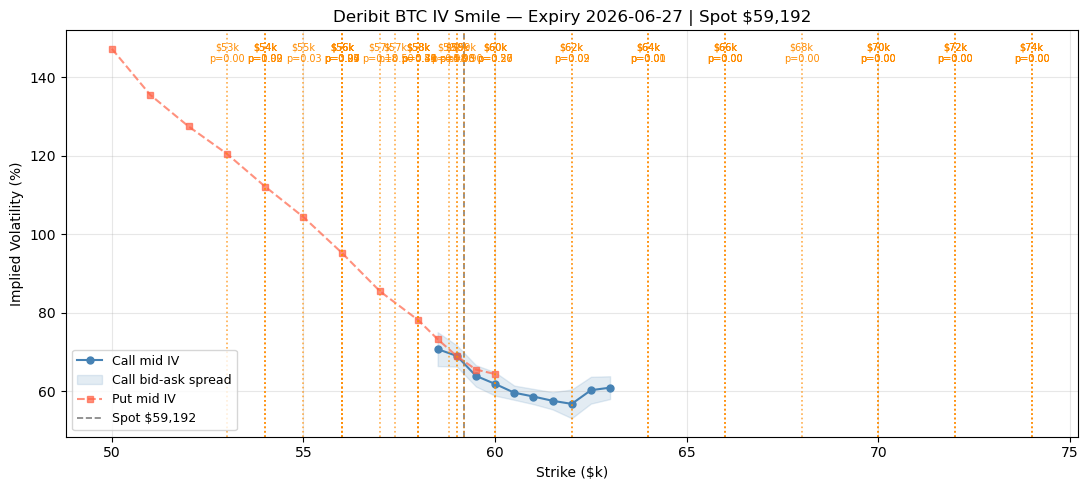

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))

chain = first_chain
spot  = chain.underlying_price
exp_str = datetime.fromtimestamp(chain.expiry_timestamp / 1000, tz=timezone.utc).strftime("%Y-%m-%d")

calls = chain.quotes[chain.quotes["option_type"] == "call"]
puts  = chain.quotes[chain.quotes["option_type"] == "put"]

ax.plot(calls["strike"] / 1000, calls["mid_iv"] * 100, "o-", color="steelblue", label="Call mid IV", ms=5)
ax.fill_between(calls["strike"] / 1000, calls["bid_iv"] * 100, calls["ask_iv"] * 100, alpha=0.15, color="steelblue", label="Call bid-ask spread")
ax.plot(puts["strike"] / 1000, puts["mid_iv"] * 100, "s--", color="tomato", label="Put mid IV", ms=5, alpha=0.7)

ax.axvline(spot / 1000, color="gray", ls="--", lw=1.2, label=f"Spot ${spot:,.0f}")

# Overlay Polymarket contract strikes for this expiry
this_exp_mask = combined_df["deribit_expiry"] == exp_str
for _, ctr in combined_df[this_exp_mask].iterrows():
    if ctr["poly_strike"] is not None:
        ax.axvline(ctr["poly_strike"] / 1000, color="darkorange", ls=":", lw=1.2, alpha=0.7)
        ax.text(ctr["poly_strike"] / 1000, ax.get_ylim()[1] * 0.98 if ax.get_ylim()[1] > 0 else 100,
                f"${ctr['poly_strike']/1000:.0f}k\np={ctr['poly_price']:.2f}",
                fontsize=7, ha="center", va="top", color="darkorange")

ax.set_xlabel("Strike ($k)")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title(f"Deribit BTC IV Smile — Expiry {exp_str} | Spot ${spot:,.0f}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary

Quick sanity checks on data quality.

In [14]:
print("=== DATA QUALITY SUMMARY ===")
print(f"\nPolymarket contracts fetched   : {len(contracts)}")
print(f"  - priceable (known strike)   : {len(priceable)}")
print(f"  - UpDown (no static strike)  : {(poly_df['bet_type'] == 'UpDown').sum()}")
print(f"  - reach (path-dependent)     : {(poly_df['bet_type'] == 'reach').sum()}")
print(f"  - strike parse failed        : {poly_df[poly_df['bet_type'].isin(['above','dip'])]['strike_low'].isna().sum()}")

print(f"\nDeribit chains fetched         : {len(chains)}")
for dts, ch in chains.items():
    d = datetime.fromtimestamp(dts / 1000, tz=timezone.utc).strftime("%Y-%m-%d")
    calls_n = (ch.quotes["option_type"]=="call").sum()
    puts_n  = (ch.quotes["option_type"]=="put").sum()
    print(f"  {d}: {len(ch.quotes)} instruments ({calls_n} calls, {puts_n} puts), spot=${ch.underlying_price:,.0f}")

print(f"\nContracts matched to chains    : {len(combined_df)}")
print(f"Basis risk > 3 days            : {(combined_df['basis_days'].abs() > 3).sum()}")

=== DATA QUALITY SUMMARY ===

Polymarket contracts fetched   : 251
  - priceable (known strike)   : 164
  - UpDown (no static strike)  : 9
  - reach (path-dependent)     : 50
  - strike parse failed        : 28

Deribit chains fetched         : 6
  2026-06-27: 23 instruments (10 calls, 13 puts), spot=$59,192
  2026-06-28: 29 instruments (14 calls, 15 puts), spot=$59,188
  2026-06-29: 27 instruments (14 calls, 13 puts), spot=$59,187
  2026-06-30: 24 instruments (12 calls, 12 puts), spot=$59,181
  2026-07-03: 29 instruments (19 calls, 10 puts), spot=$59,191
  2026-12-25: 82 instruments (56 calls, 26 puts), spot=$60,249

Contracts matched to chains    : 164
Basis risk > 3 days            : 13
